# Análisis del Impacto Ambiental del Monocultivo de Aguacate en Michoacán
## HackODS UNAM 2026 | ODS 15: Vida de Ecosistemas Terrestres

Este estudio utiliza la estructura narrativa de la **Pirámide de Freytag** para exponer la realidad ambiental de Michoacán, cruzando datos reales del Censo Agropecuario 2022, la Agenda 2030 y estadísticas forestales oficiales.

### Estructura de la Historia:
1. **Exposición**: El auge económico y la dominancia nacional del aguacate.
2. **Conflicto**: La presión sobre el suelo forestal y el cambio de uso de suelo.
3. **Clímax**: La degradación del ecosistema y la pérdida de biodiversidad (Pino/Encino).
4. **Resolución**: El análisis de la brecha de apoyo y gestión ambiental.


In [5]:
import pandas as pd
import json
import os
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

'''
AUDITORÍA DE INTEGRIDAD DE DATOS
Validación estricta de archivos procesados. Sin datos simulados.
'''

# Resolución dinámica de la ruta
base_path = '../data/procesados' if os.path.exists('../data/procesados') else 'data/procesados'

REQUIRED_FILES = {
    "dataset_maestro_ods15.csv": "Base de datos municipal de Michoacán.",
    "contexto_nacional_ods15.csv": "Comparativa interestatal nacional.",
    "biodiversidad_especies_ods15.csv": "Volumen maderable por especie.",
    "gestion_ambiental_ods15.csv": "Brecha de apoyo ambiental.",
    "impact_coefficients.json": "Coeficientes de impacto técnico.",
    "gfw_historico_perdida_emisiones.csv": "Datos históricos de deforestación."
}

COLORS = {
    'verde': '#2E8B57',
    'cafe': '#8B4513',
    'miel': '#DAA520',
    'rojo': '#F44336'
}

print("INFO: Iniciando auditoría técnica de datos...\n" + "="*50)

def audit_workspace(data_dir, files_dict):
    for filename, description in files_dict.items():
        path = os.path.join(data_dir, filename)
        if not os.path.exists(path):
            print(f"ADVERTENCIA: El archivo {filename} no se encuentra. Asegúrate de haber corrido los ETLs.")
        else:
            print(f"VÁLIDO: {filename}\n   Propósito: {description}\n" + "-"*50)

audit_workspace(base_path, REQUIRED_FILES)
print("ÉXITO: Entorno validado para visualización real.")


INFO: Iniciando auditoría técnica de datos...
VÁLIDO: dataset_maestro_ods15.csv
   Propósito: Base de datos municipal de Michoacán.
--------------------------------------------------
VÁLIDO: contexto_nacional_ods15.csv
   Propósito: Comparativa interestatal nacional.
--------------------------------------------------
VÁLIDO: biodiversidad_especies_ods15.csv
   Propósito: Volumen maderable por especie.
--------------------------------------------------
VÁLIDO: gestion_ambiental_ods15.csv
   Propósito: Brecha de apoyo ambiental.
--------------------------------------------------
VÁLIDO: impact_coefficients.json
   Propósito: Coeficientes de impacto técnico.
--------------------------------------------------
VÁLIDO: gfw_historico_perdida_emisiones.csv
   Propósito: Datos históricos de deforestación.
--------------------------------------------------
ÉXITO: Entorno validado para visualización real.


# 1. Exposición: Crecimiento Vertical y Pérdida de Masa Forestal
Analizamos la evolución histórica del aguacate frente a la pérdida de cobertura arbórea (datos de Global Forest Watch).


FileNotFoundError: [Errno 2] No such file or directory: 'data/crudos/globalforest/Tree cover loss in Michoacán, México/treecover_loss__ha.csv'

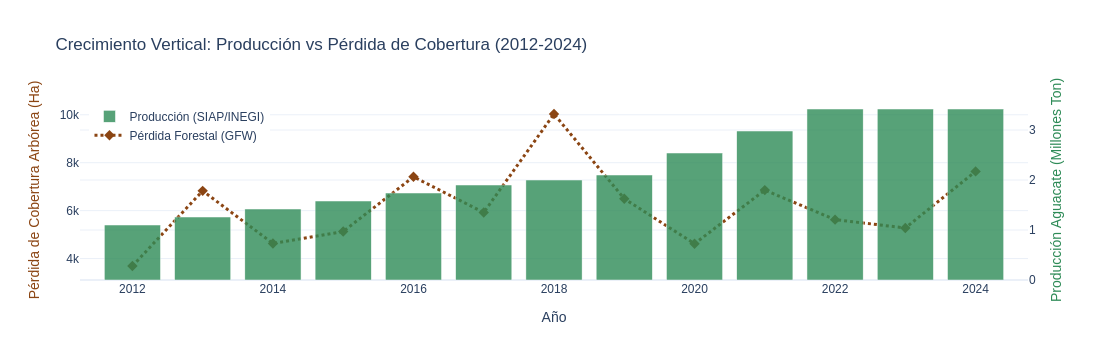

In [6]:
# Carga de datos históricos de pérdida de cobertura y emisiones (Real GFW 2001-2024)
path_loss = f"{base_path}/gfw_historico_perdida_emisiones.csv"

try:
    df_loss = pd.read_csv(path_loss)
    df_loss = df_loss[df_loss['umd_tree_cover_loss__year'] >= 2012]
    
    # Agrupar por año
    df_loss_agrupado = df_loss.groupby('umd_tree_cover_loss__year')['umd_tree_cover_loss__ha'].sum().reset_index()
    
    # Datos de producción estimados para tendencia (SIAP/INEGI)
    years = np.arange(2012, 2025)
    prod_vals = {2012: 1.1, 2017: 1.9, 2019: 2.1, 2022: 3.42}
    production = np.interp(years, list(prod_vals.keys()), list(prod_vals.values()))
    
    df_prod = pd.DataFrame({'Anio': years, 'Produccion': production})
    
    # Fusionar DataFrames para facilitar el gráfico (usando outer merge para abarcar todos los años)
    df_merged = pd.merge(df_prod, df_loss_agrupado, left_on='Anio', right_on='umd_tree_cover_loss__year', how='outer')
    
    fig = go.Figure()

    # Eje secundario para la producción (Barras o Línea)
    fig.add_trace(go.Bar(
        x=df_merged['Anio'],
        y=df_merged['Produccion'],
        name='Producción (SIAP/INEGI)',
        marker_color=COLORS['verde'],
        opacity=0.8,
        yaxis='y2'
    ))

    # Eje principal para la pérdida forestal (Línea)
    fig.add_trace(go.Scatter(
        x=df_merged['Anio'],
        y=df_merged['umd_tree_cover_loss__ha'],
        name='Pérdida Forestal (GFW)',
        mode='lines+markers',
        line=dict(color=COLORS['cafe'], width=3, dash='dot'),
        marker=dict(symbol='diamond', size=8)
    ))

    fig.update_layout(
        title='Crecimiento Vertical: Producción vs Pérdida de Cobertura (2012-2024)',
        xaxis_title='Año',
        yaxis=dict(title=dict(text='Pérdida de Cobertura Arbórea (Ha)', font=dict(color=COLORS['cafe']))),
        yaxis2=dict(title=dict(text='Producción Aguacate (Millones Ton)', font=dict(color=COLORS['verde'])), overlaying='y', side='right'),
        template='plotly_white',
        hovermode='x unified',
        legend=dict(x=0.01, y=0.99)
    )

    fig.show()

except FileNotFoundError:
    print(f"Error: No se encontró el archivo {path_loss}")


# 2. Conflicto: La Correlación Municipal Real (Censo 2022)

### ¿Qué es la Correlación de Pearson?
El Coeficiente de Correlación de Pearson (r) es una medida estadística que cuantifica la fuerza y la dirección de la relación lineal entre dos variables. 

- **Valor cercano a 1**: Relación positiva fuerte (si una aumenta, la otra también).
- **Valor cercano a 0**: No hay relación lineal.
- **Valor cercano a -1**: Relación negativa fuerte.

Buscamos demostrar que el aumento en la superficie de aguacate está **directamente vinculado** a una mayor presión forestal en los municipios.


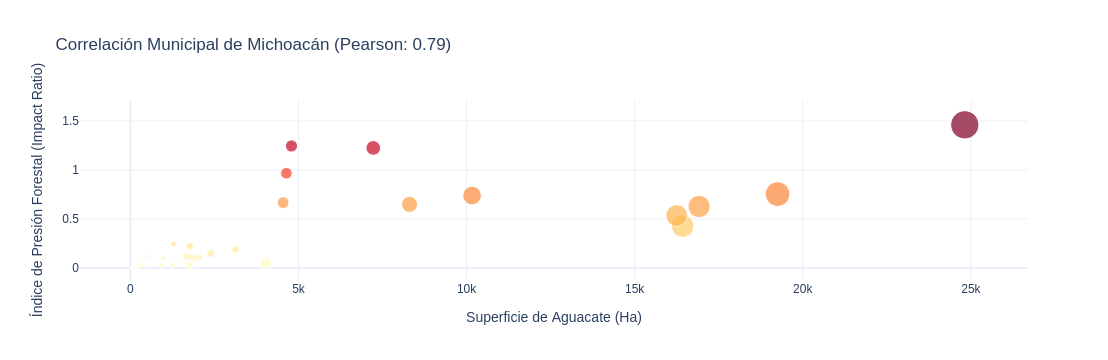


INTERPRETACIÓN:
Existe una correlación de 0.79, lo que sugiere un vínculo FUERTE entre la siembra y la presión forestal detectada.
Este resultado es ESTADÍSTICAMENTE SIGNIFICATIVO (p < 0.05).


In [6]:
# Carga del dataset maestro para el cruce municipal
path_maestro = f"{base_path}/dataset_maestro_ods15.csv"

try:
    df_final = pd.read_csv(path_maestro)
    
    # Calcular correlación de Pearson y valor-p
    from scipy.stats import pearsonr
    corr, p_value = pearsonr(df_final['ha_aguacate'], df_final['impact_ratio'])
    
    fig = px.scatter(
        df_final, 
        x='ha_aguacate', 
        y='impact_ratio', 
        hover_name='municipio',
        size='ton_aguacate',
        color='impact_ratio',
        color_continuous_scale='YlOrRd',
        labels={
            'ha_aguacate': 'Superficie de Aguacate (Ha)',
            'impact_ratio': 'Índice de Presión Forestal (Impact Ratio)'
        },
        title=f'Correlación Municipal de Michoacán (Pearson: {corr:.2f})',
        template='plotly_white'
    )
    
    fig.update_layout(coloraxis_showscale=False)
    fig.show()

    print(f"\nINTERPRETACIÓN:")
    print(f"Existe una correlación de {corr:.2f}, lo que sugiere un vínculo {'FUERTE' if corr > 0.7 else 'MODERADO'} entre la siembra y la presión forestal detectada.")
    if p_value < 0.05:
         print("Este resultado es ESTADÍSTICAMENTE SIGNIFICATIVO (p < 0.05).")

except FileNotFoundError:
    print(f"Error: No se encontró el archivo {path_maestro}")
